# 05 - Feature-based models

**Part 5: covariates.** Builds the supervised-learning feature table from sensor, weather, time-based, and lagged appliance-use variables, and checks it for leakage.

The feature-based model itself (Part 6) is added to this notebook in the next stage. All construction logic lives in `appliance_energy.features` and is rebuilt by `scripts/make_features.py`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data, features, plotting

config.ensure_dirs()
hourly = data.load_hourly_data()
print(f"Hourly data: {hourly.shape[0]} rows x {hourly.shape[1]} columns")
print("Measured columns:", list(hourly.columns))

Hourly data: 3290 rows x 28 columns
Measured columns: ['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


## 1. Which covariates, and why

The dataset already supplies indoor sensors, outdoor weather, and a lighting meter. Three further groups are derived from it:

| Group | Source | Examples |
|---|---|---|
| Calendar | derived from the timestamp | `hour`, `dayofweek`, `is_weekend`, cyclical sin/cos pairs |
| Lag | derived from the target | `lag_24`, `lag_48`, `lag_168` |
| Rolling | derived from the target | `roll_mean_24`, `roll_std_168` |
| Indoor | measured (+ derived aggregates) | `T1`-`T9`, `RH_1`-`RH_9`, `indoor_temp_mean` |
| Outdoor | measured | `T_out`, `RH_out`, `Windspeed`, `Tdewpoint` |
| House | measured | `lights` |

Hour and day-of-week are encoded as sine/cosine pairs so the model treats them as cyclical -- hour 23 and hour 0 are adjacent, which a raw integer cannot express. The nine indoor sensors are strongly correlated with each other, so house-level aggregates (mean, spread, and the indoor/outdoor gradient) capture most of the signal more compactly.

## 2. The horizon constraint on lag features

This is the critical design decision. At forecast origin `o` we predict `o+1 ... o+24`. For the step at `o+24`, a `lag_1` feature would require the target at `o+23` -- which lies *inside the block being predicted* and is not observed at the origin.

So a feature attached to row `t` may only use target values from `t - 24` or earlier. Short lags (`lag_1`, `lag_2`, `lag_12`) are perfectly valid for one-step-ahead forecasting, but at a 24-hour horizon they leak future information and inflate test scores. The same applies to rolling features: shifting by one step before the window -- the common recipe -- leaks here, so we shift by the full horizon instead.

`add_lag_features` enforces this and reports anything it drops.

In [2]:
# Requesting unsafe lags: they are refused and reported.
demo = features.add_lag_features(
    hourly, lags=[1, 2, 12, 24, 168], horizon=config.HORIZON)

print("\nLag columns kept:", [c for c in demo.columns if c.startswith("lag_")])

Dropping lags [1, 2, 12]: shorter than the 24-step horizon, so they would use unobserved values.

Lag columns kept: ['lag_24', 'lag_168']


In [3]:
# Quantify the difference between the safe and leaky constructions.
safe = features.add_rolling_features(
    hourly, windows=[24], horizon=config.HORIZON)
leaky = features.add_rolling_features(
    hourly, windows=[24], horizon=config.HORIZON, allow_leaky=True)

target = hourly[config.TARGET]

comparison = pd.DataFrame({
    "lag_1 (leaky at h=24)": target.shift(1),
    "lag_24 (safe)": target.shift(24),
    "roll_mean_24 shifted by 1 (leaky)": leaky["roll_mean_24"],
    "roll_mean_24 shifted by 24 (safe)": safe["roll_mean_24"],
}).corrwith(target).rename("corr_with_target").to_frame().round(3)

comparison

,corr_with_target
lag_1 (leaky at h=24),0.581
lag_24 (safe),0.307
roll_mean_24 shifted by 1 (leaky),0.178
roll_mean_24 shifted by 24 (safe),0.004


The leaky variants correlate far more strongly with the target simply because they contain observations from within the forecast window. A model given them would score well on the test set while being impossible to run in practice -- precisely the failure mode the assignment's leakage guidance warns about, and the reason the demo pipeline's `lag_1 ... lag_12` features are not reused here.

## 3. Build the feature table

In [4]:
table = features.build_feature_table(
    hourly, target=config.TARGET, horizon=config.HORIZON)

print(f"Feature table: {table.shape[0]} rows x {table.shape[1]} columns")
print(f"Warm-up rows dropped: {len(hourly) - len(table)} "
      f"(longest lag/window = 168 h + {config.HORIZON} h shift)")
print(f"Missing values: {int(table.isna().sum().sum())}")
table.head()

Feature table: 3099 rows x 51 columns


Warm-up rows dropped: 191 (longest lag/window = 168 h + 24 h shift)
Missing values: 0


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,lag_26,lag_48,lag_72,lag_168,roll_mean_24,roll_std_24,roll_mean_48,roll_std_48,roll_mean_168,roll_std_168
date,,,,,,,,,,,,,,,,,,,,,
2016-01-19 16:00:00,41.666667,0.000000,19.323333,40.150000,18.083333,40.335556,19.044444,39.500000,18.187778,37.476667,...,41.666667,81.666667,75.000000,40.000000,79.305556,94.560919,119.548611,118.448770,113.898810,99.261718
2016-01-19 17:00:00,71.666667,5.000000,19.210000,39.651111,17.905000,40.279722,19.000000,39.593472,17.974444,37.296667,...,33.333333,455.000000,265.000000,218.333333,61.805556,50.702592,114.756944,117.083849,113.779762,99.344738
2016-01-19 18:00:00,175.000000,8.333333,19.055556,39.107778,17.666667,39.838889,18.752778,38.732778,17.795833,37.476111,...,46.666667,268.333333,473.333333,58.333333,63.125000,56.402437,111.145833,108.119077,114.513889,100.263683
2016-01-19 19:00:00,353.333333,10.000000,19.066667,40.189444,17.773333,40.152222,18.913889,39.517222,17.650000,37.216667,...,35.000000,101.666667,391.666667,55.000000,67.013889,62.104749,107.048611,100.736789,114.642857,100.353690
2016-01-19 20:00:00,448.333333,15.000000,19.375556,40.698333,18.253333,40.406667,20.291528,42.741250,18.033333,36.596111,...,300.000000,110.000000,118.333333,51.666667,85.694444,117.931976,116.215278,119.968839,117.222222,106.029890


In [5]:
groups = features.feature_groups(table.columns)

for name, cols in groups.items():
    print(f"{name:9s} ({len(cols):2d}): {', '.join(cols)}")

calendar  ( 7): hour, dayofweek, is_weekend, hour_sin, hour_cos, dow_sin, dow_cos
lag       ( 6): lag_24, lag_25, lag_26, lag_48, lag_72, lag_168
rolling   ( 6): roll_mean_24, roll_std_24, roll_mean_48, roll_std_48, roll_mean_168, roll_std_168
indoor    (24): T1, RH_1, T2, RH_2, T3, RH_3, T4, RH_4, T5, RH_5, T6, RH_6, T7, RH_7, T8, RH_8, T9, RH_9, indoor_temp_mean, indoor_temp_std, indoor_temp_range, indoor_rh_mean, indoor_rh_std, indoor_outdoor_temp_diff
outdoor   ( 6): T_out, Press_mm_hg, RH_out, Windspeed, Visibility, Tdewpoint
house     ( 1): lights


Saved figure to D:\UK ass\outputs\figures\05_feature_groups.png


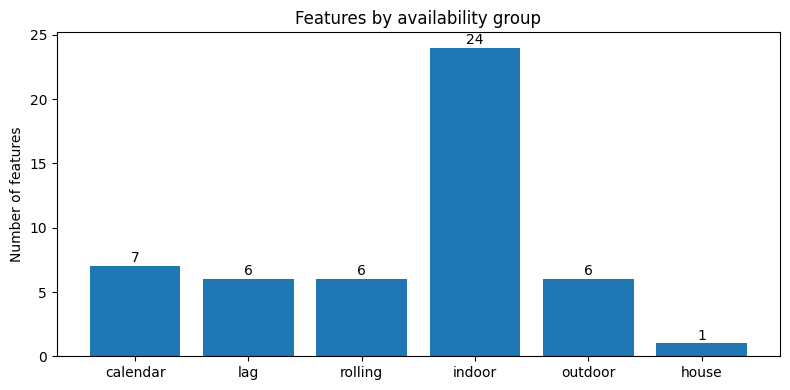

In [6]:
fig = plotting.plot_group_sizes(groups)
plotting.save_fig(fig, config.FIGURE_DIR / "05_feature_groups.png")
plt.show()

## 4. Which covariates would be known at the forecast origin?

A covariate being *useful* is not the same as it being *available*. Calendar features are known indefinitely ahead. Lag and rolling features are known provided they respect the horizon rule above. But indoor sensors, outdoor weather, and the lighting meter are all **measurements** -- their future values do not exist at the forecast origin.

Feeding a model the realised test-set values of those variables produces a **conditional forecast** (conditional on knowing the future weather and sensor readings), not a true operational forecast.

In [7]:
known = features.known_at_origin_columns(table.columns)
all_features = [c for c in table.columns if c != config.TARGET]
conditional = [c for c in all_features if c not in known]

print(f"Known at origin  ({len(known):2d}): {', '.join(known)}")
print()
print(f"Needs realised values ({len(conditional):2d}): {', '.join(conditional)}")
print()
print(f"-> {len(conditional)/len(all_features):.0%} of the feature table "
      "would be unavailable in a real deployment.")

Known at origin  (19): hour, dayofweek, is_weekend, hour_sin, hour_cos, dow_sin, dow_cos, lag_24, lag_25, lag_26, lag_48, lag_72, lag_168, roll_mean_24, roll_std_24, roll_mean_48, roll_std_48, roll_mean_168, roll_std_168

Needs realised values (31): lights, T1, RH_1, T2, RH_2, T3, RH_3, T4, RH_4, T5, RH_5, T6, RH_6, T7, RH_7, T8, RH_8, T9, RH_9, T_out, Press_mm_hg, RH_out, Windspeed, Visibility, Tdewpoint, indoor_temp_mean, indoor_temp_std, indoor_temp_range, indoor_rh_mean, indoor_rh_std, indoor_outdoor_temp_diff

-> 62% of the feature table would be unavailable in a real deployment.


In Part 6 this split lets us train two variants -- one restricted to genuinely-known covariates, one using everything -- and report the difference honestly rather than presenting a conditional forecast as though it were operational.

## 5. How the covariates relate to the target

Saved figure to D:\UK ass\outputs\figures\05_feature_correlations.png


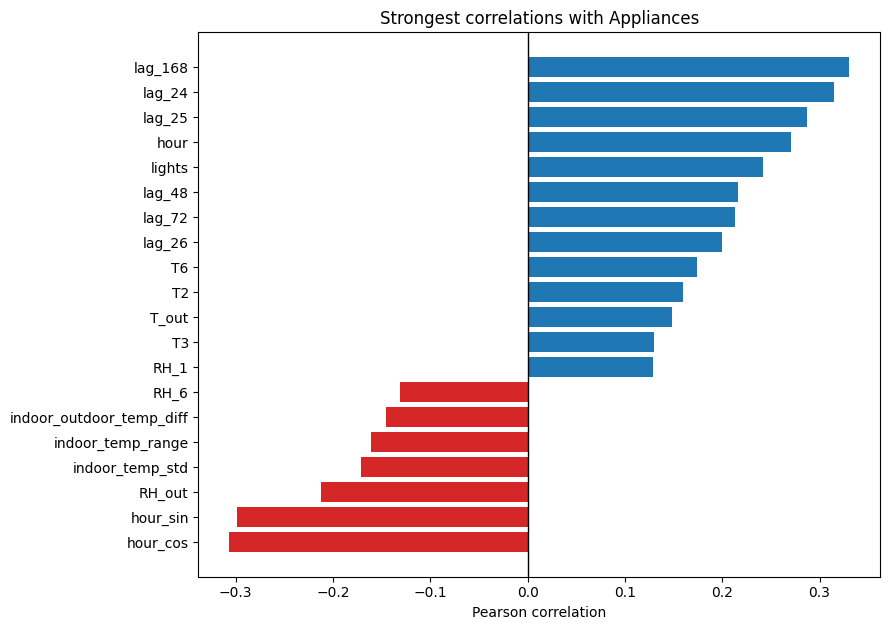

lag_168                     0.330
lag_24                      0.315
hour_cos                   -0.306
hour_sin                   -0.299
lag_25                      0.287
hour                        0.271
lights                      0.242
lag_48                      0.217
lag_72                      0.213
RH_out                     -0.212
lag_26                      0.200
T6                          0.174
indoor_temp_std            -0.172
indoor_temp_range          -0.161
T2                          0.160
T_out                       0.148
indoor_outdoor_temp_diff   -0.146
RH_6                       -0.131
T3                          0.130
RH_1                        0.129
Name: Appliances, dtype: float64

In [8]:
fig, correlations = plotting.plot_target_correlations(
    table, target=config.TARGET, top_n=20,
    title="Strongest correlations with Appliances")
plotting.save_fig(fig, config.FIGURE_DIR / "05_feature_correlations.png")
plt.show()

correlations.sort_values(key=abs, ascending=False).round(3)

In [9]:
# Strongest correlate within each availability group.
corr_all = table.corr(numeric_only=True)[config.TARGET].drop(config.TARGET)

summary = []
for name, cols in groups.items():
    if not cols:
        continue
    group_corr = corr_all[cols].abs()
    summary.append({
        "group": name,
        "n_features": len(cols),
        "max_abs_corr": group_corr.max(),
        "strongest": group_corr.idxmax(),
        "mean_abs_corr": group_corr.mean(),
    })

pd.DataFrame(summary).sort_values("max_abs_corr", ascending=False).round(3)

,group,n_features,max_abs_corr,strongest,mean_abs_corr
1,lag,6,0.330,lag_168,0.260
0,calendar,7,0.306,hour_cos,0.141
5,house,1,0.242,lights,0.242
4,outdoor,6,0.212,RH_out,0.093
3,indoor,24,0.174,T6,0.091
2,rolling,6,0.081,roll_mean_168,0.036


Two things stand out. **Lag features are the strongest group**, which matches the benchmark and SARIMAX findings that recent history and the daily cycle carry most of the signal. **The rolling features are the weakest** -- once shifted by a full 24 hours, a 24-hour average says little about any specific future hour, because appliance use is spiky rather than smoothly varying. They are retained as a level/volatility context rather than as strong predictors, and Part 6's feature-group ablation will test whether they earn their place.

In [10]:
# Indoor sensors are highly collinear, which is why aggregates are useful.
temp_cols = [c for c in config.INDOOR_TEMP_COLS if c in table.columns]
indoor_corr = table[temp_cols].corr()

upper = indoor_corr.where(np.triu(np.ones(indoor_corr.shape), k=1).astype(bool))
print(f"Indoor temperature sensors T1-T9:")
print(f"  mean pairwise correlation: {upper.stack().mean():.3f}")
print(f"  max  pairwise correlation: {upper.stack().max():.3f}")

Indoor temperature sensors T1-T9:
  mean pairwise correlation: 0.793
  max  pairwise correlation: 0.948


Saved figure to D:\UK ass\outputs\figures\05_daily_profile_weekend.png


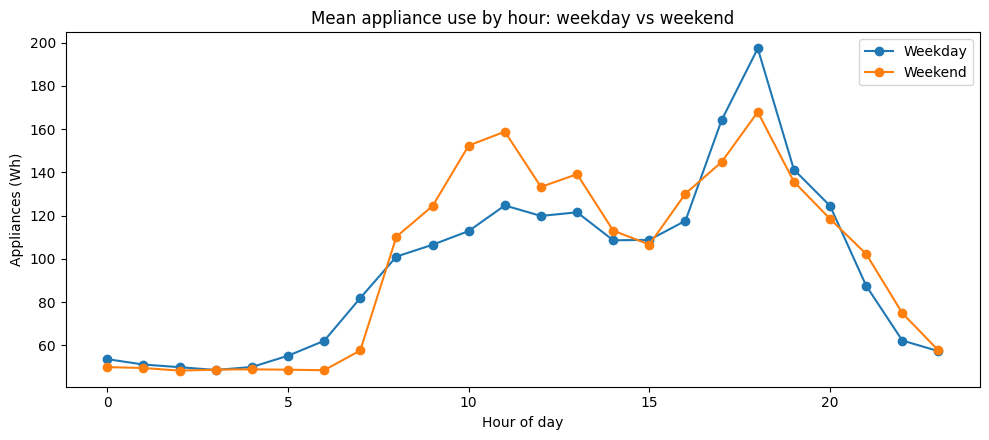

In [11]:
# Daily profile by weekday vs weekend, the signal the calendar features encode.
profile = table.groupby(["is_weekend", "hour"])[config.TARGET].mean().unstack(0)
profile.columns = ["Weekday", "Weekend"]

fig, ax = plt.subplots(figsize=(10, 4.5))
profile.plot(ax=ax, marker="o")
ax.set_title("Mean appliance use by hour: weekday vs weekend")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Appliances (Wh)")
fig.tight_layout()
plotting.save_fig(fig, config.FIGURE_DIR / "05_daily_profile_weekend.png")
plt.show()

## 6. Save the feature table

In [12]:
table.to_csv(config.FEATURE_TABLE_PATH)
print(f"Saved to {config.FEATURE_TABLE_PATH}")
print(f"{table.shape[0]} rows x {table.shape[1]} columns")

Saved to D:\UK ass\data\processed\feature_table.csv
3099 rows x 51 columns


---

# Part 6 - Feature-based regression model

Fits a feature-based regressor to the table built above, using the final 14 days as the test period and a 24-hour forecast horizon.

**Selection protocol.** The brief lists *"choosing the final model based only on test-set performance"* as data leakage. Both the feature set and the model family are therefore chosen on a **validation block** -- the 14 days immediately before the test period -- and the test set is scored exactly once, at the end.

In [13]:
from appliance_energy import backtest, evaluation
from appliance_energy.models import benchmarks, feature_models, sarimax

y_full = hourly[config.TARGET].asfreq("h")
train_full, test_full = data.train_test_split_series(
    y_full, test_steps=config.TEST_STEPS)

split = feature_models.split_train_valid_test(table)

for part in ["train", "valid", "test"]:
    idx = split[f"y_{part}"].index
    print(f"{part:5s}: {len(idx):4d} rows  {idx.min()} .. {idx.max()}")

assert split["y_test"].index.equals(test_full.index), \
    "feature-model test block must match the other models"
print("\nTest block matches the benchmark/SARIMAX test period.")

train: 2427 rows  2016-01-19 16:00:00 .. 2016-04-29 18:00:00
valid:  336 rows  2016-04-29 19:00:00 .. 2016-05-13 18:00:00
test :  336 rows  2016-05-13 19:00:00 .. 2016-05-27 18:00:00

Test block matches the benchmark/SARIMAX test period.


## 7. Which feature groups actually help?

Groups are added cumulatively, in order of how available they would be in deployment, and each candidate is scored on the **validation** block.

In [14]:
def evaluate_fn(y_true, y_pred):
    return evaluation.evaluate_forecast("candidate", y_true, y_pred, train_full)

ablation = feature_models.run_feature_group_ablation(
    table, evaluate_fn, name="xgboost", evaluate_on="valid")

ablation[["added_group", "n_features", "MAE", "RMSE", "MASE", "known_at_origin"]].round(3)

,added_group,n_features,MAE,RMSE,MASE,known_at_origin
0,calendar,7,39.591,62.015,0.741,True
1,lag,13,35.500,58.447,0.664,True
2,rolling,19,47.365,68.929,0.887,True
3,house,20,45.400,68.294,0.850,False
4,indoor,44,78.024,105.794,1.460,False
5,outdoor,50,78.139,104.667,1.463,False


Saved figure to D:\UK ass\outputs\figures\05_feature_ablation.png


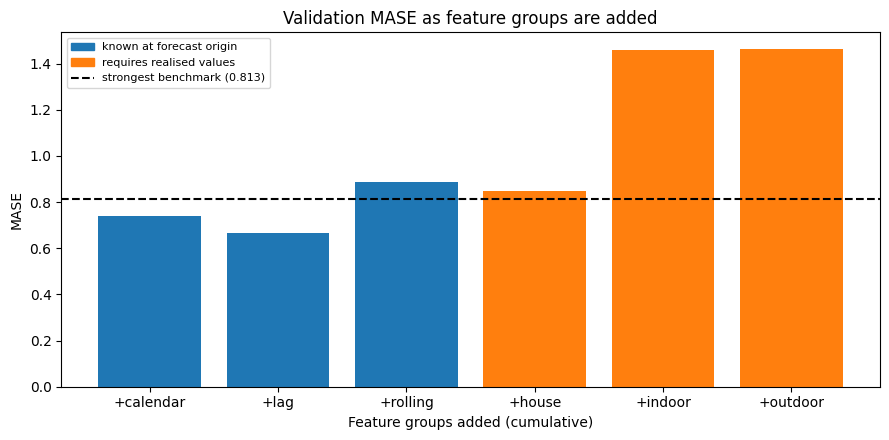

In [15]:
strongest_benchmark = backtest.rolling_origin_forecast(
    benchmarks.seasonal_naive_forecast, train_full, test_full,
    horizon=config.HORIZON, seasonality=config.WEEKLY_PERIOD)
benchmark_mase = evaluation.evaluate_forecast(
    "snaive_weekly", test_full, strongest_benchmark, train_full)["MASE"]

fig = plotting.plot_ablation(
    ablation, metric="MASE", baseline=benchmark_mase,
    title="Validation MASE as feature groups are added")
plotting.save_fig(fig, config.FIGURE_DIR / "05_feature_ablation.png")
plt.show()

**Adding more covariates makes the model worse.** Calendar plus lag features give the best validation score; every group added after that degrades it, and the indoor sensors are actively harmful (MASE roughly doubles).

Two reasons. First, the sensor and weather readings are only weakly related to appliance use once the daily cycle is already captured -- Part 5 showed their correlations are small -- so 31 extra columns mostly add variance for the trees to fit. Second, indoor temperature and humidity drift slowly over the season, so the model can latch onto levels seen in training that no longer hold two weeks later; the test and validation periods sit at the end of a warming spring.

This is a useful negative result: the covariates required by Part 5 are *available*, but they are not *helpful* here.

## 8. Select the feature set and model family on validation

In [16]:
chosen_groups = feature_models.select_groups_by_validation(ablation, metric="MASE")
chosen_cols = feature_models.columns_for_groups(table, chosen_groups)

print(f"Chosen groups   : {chosen_groups}")
print(f"Chosen features : {len(chosen_cols)} -> {chosen_cols}")

Chosen groups   : ['calendar', 'lag']
Chosen features : 13 -> ['hour', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_24', 'lag_25', 'lag_26', 'lag_48', 'lag_72', 'lag_168']


In [17]:
sel = feature_models.split_train_valid_test(table, feature_cols=chosen_cols)

family_scores = []
for name in config.FEATURE_MODEL_CANDIDATES:
    m = feature_models.fit_feature_model(sel["X_train"], sel["y_train"], name=name)
    p = feature_models.predict_feature_model(m, sel["X_valid"], index=sel["y_valid"].index)
    row = evaluation.evaluate_forecast(name, sel["y_valid"], p, train_full)
    family_scores.append(row)

family_df = pd.DataFrame(family_scores).sort_values("MASE").reset_index(drop=True)
family_df.round(3)

,model,MAE,RMSE,MASE,Bias
0,random_forest,33.538,54.960,0.628,5.490
1,xgboost,35.500,58.447,0.664,5.302
2,histgb,36.726,60.839,0.687,6.280


In [18]:
best_family = family_df.loc[0, "model"]
print(f"Model family chosen on validation: {best_family}")

Model family chosen on validation: random_forest


## 9. Refit and score once on the test period

The final model is refitted on training + validation data, then evaluated on the untouched test block.

In [19]:
X_fit = pd.concat([sel["X_train"], sel["X_valid"]])
y_fit = pd.concat([sel["y_train"], sel["y_valid"]])

final_model = feature_models.fit_feature_model(X_fit, y_fit, name=best_family)
feature_pred = feature_models.predict_feature_model(
    final_model, sel["X_test"], index=sel["y_test"].index, name="feature_model")

# Contrast: the same family trained on all 50 features.
allf = feature_models.split_train_valid_test(table)
model_all = feature_models.fit_feature_model(
    pd.concat([allf["X_train"], allf["X_valid"]]),
    pd.concat([allf["y_train"], allf["y_valid"]]), name=best_family)
pred_all = feature_models.predict_feature_model(
    model_all, allf["X_test"], index=allf["y_test"].index, name="feature_model_all")

print("Fitted final model and all-features contrast.")

Fitted final model and all-features contrast.


### 24-hour forecast

The first block of the test period, as Part 6 requires.

24-hour RMSE : 41.07 Wh
24-hour MAE  : 27.08 Wh


Saved figure to D:\UK ass\outputs\figures\05_feature_model_24h_forecast.png


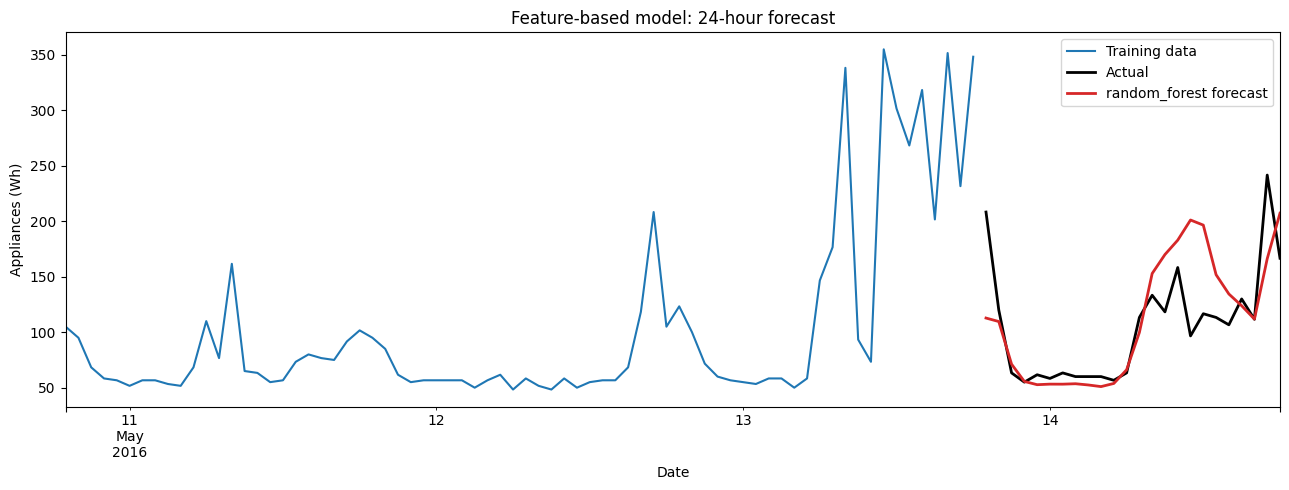

In [20]:
h = config.HORIZON
actual_24h = sel["y_test"].iloc[:h]
pred_24h = feature_pred.iloc[:h]

print(f"24-hour RMSE : {evaluation.rmse(actual_24h, pred_24h):.2f} Wh")
print(f"24-hour MAE  : {evaluation.mae(actual_24h, pred_24h):.2f} Wh")

fig, ax = plt.subplots(figsize=(13, 5))
train_full.tail(72).plot(ax=ax, label="Training data", linewidth=1.5)
actual_24h.plot(ax=ax, label="Actual", color="black", linewidth=2)
pred_24h.plot(ax=ax, label=f"{best_family} forecast", color="tab:red", linewidth=2)
ax.set_title("Feature-based model: 24-hour forecast")
ax.set_ylabel("Appliances (Wh)")
ax.set_xlabel("Date")
ax.legend()
fig.tight_layout()
plotting.save_fig(fig, config.FIGURE_DIR / "05_feature_model_24h_forecast.png")
plt.show()

## 10. Comparison against every previous model

In [21]:
forecasts = {
    "mean": backtest.rolling_origin_forecast(
        benchmarks.mean_forecast, train_full, test_full, horizon=config.HORIZON),
    "naive": backtest.rolling_origin_forecast(
        benchmarks.naive_forecast, train_full, test_full, horizon=config.HORIZON),
    "seasonal_naive_daily": backtest.rolling_origin_forecast(
        benchmarks.seasonal_naive_forecast, train_full, test_full,
        horizon=config.HORIZON, seasonality=config.DAILY_PERIOD),
    "seasonal_naive_weekly": strongest_benchmark,
}

sarimax_fit = sarimax.load_model()
sarimax_roll = sarimax.rolling_forecast_sarimax(
    sarimax_fit, test_full, horizon=config.HORIZON)
forecasts["sarimax"] = sarimax_roll["sarimax"]

forecasts["feature_model"] = feature_pred
forecasts["feature_model_all_features"] = pred_all

results = evaluation.evaluate_all(
    forecasts, test_full, train_full, seasonality=config.DAILY_PERIOD)
results.round(3)

,model,MAE,RMSE,MASE,Bias
0,feature_model,35.384,62.033,0.662,-2.373
1,sarimax,36.255,64.736,0.679,-6.325
2,feature_model_all_features,40.709,64.469,0.762,7.587
3,seasonal_naive_weekly,43.457,81.409,0.813,-13.160
4,seasonal_naive_daily,48.309,85.565,0.904,1.751
5,mean,50.258,74.938,0.941,-3.287
6,naive,85.551,110.390,1.601,50.977


In [22]:
# The same 24-hour block, scored for SARIMAX, for a like-for-like read.
single_block = pd.DataFrame({
    "model": ["feature_model", "sarimax"],
    "RMSE_first_24h": [
        evaluation.rmse(actual_24h, pred_24h),
        evaluation.rmse(actual_24h, sarimax_roll["sarimax"].iloc[:h]),
    ],
    "MASE_full_test": [
        evaluation.evaluate_forecast(
            "f", test_full, feature_pred, train_full)["MASE"],
        evaluation.evaluate_forecast(
            "s", test_full, sarimax_roll["sarimax"], train_full)["MASE"],
    ],
})
single_block.round(3)

,model,RMSE_first_24h,MASE_full_test
0,feature_model,41.074,0.662
1,sarimax,26.763,0.679


On this particular day SARIMAX is the more accurate of the two, even though the feature model wins comfortably across the full test period. That is not a contradiction, it is sample size: one 24-hour block is a single draw, and the first block also happens to be where SARIMAX's short-horizon steps help it most. The 14-block average is the figure to trust, and it is the one reported in the comparison table below.

Saved figure to D:\UK ass\outputs\figures\05_feature_model_comparison.png


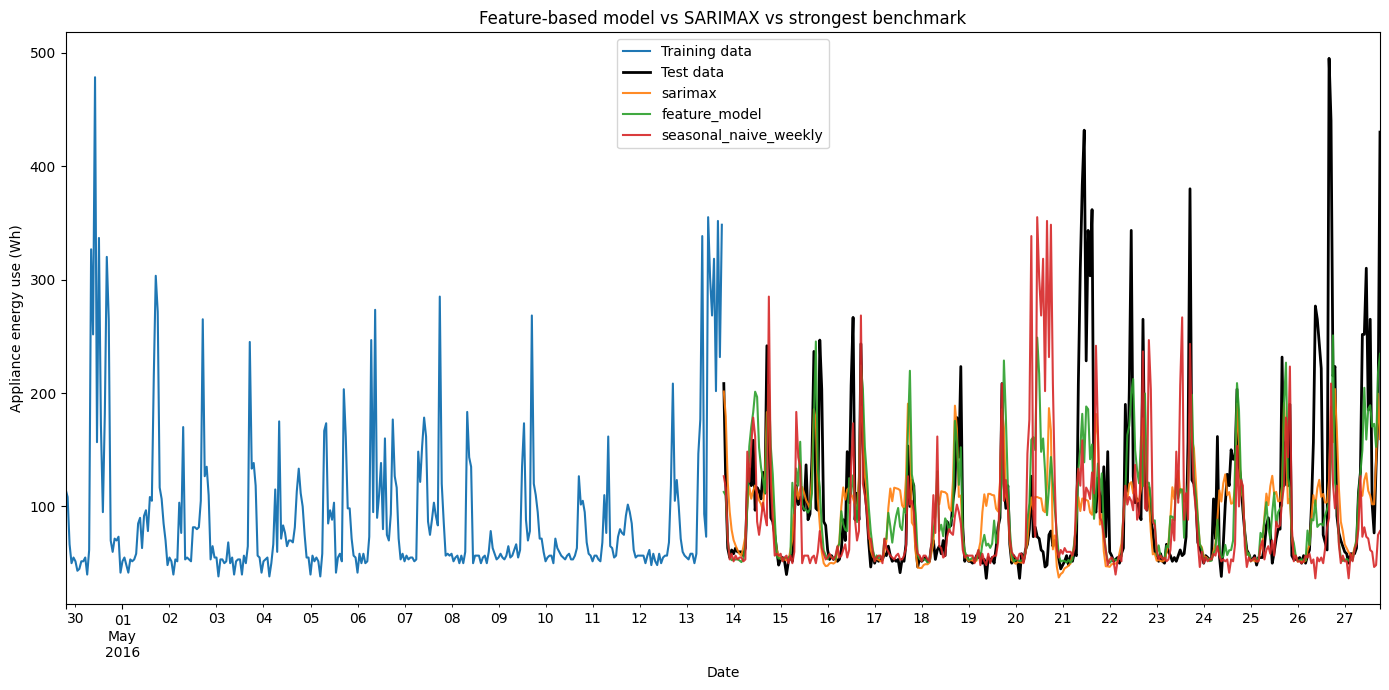

In [23]:
fig = plotting.plot_forecasts(
    train_full, test_full,
    pd.DataFrame({"actual": test_full,
                  "sarimax": forecasts["sarimax"],
                  "feature_model": feature_pred,
                  "seasonal_naive_weekly": strongest_benchmark}),
    title="Feature-based model vs SARIMAX vs strongest benchmark")
plotting.save_fig(fig, config.FIGURE_DIR / "05_feature_model_comparison.png")
plt.show()

## 11. Is the comparison with SARIMAX fair?

Not exactly, and the difference favours SARIMAX. Its rolling blocks forecast `o+1 ... o+24` from origin `o`, so the first step of each block is only one hour ahead. The feature model predicts every row a full 24 hours ahead, because its lag features are all built at a 24-hour remove.

Breaking the error down by position within each block makes the asymmetry visible.

Saved figure to D:\UK ass\outputs\figures\05_error_by_step_ahead.png


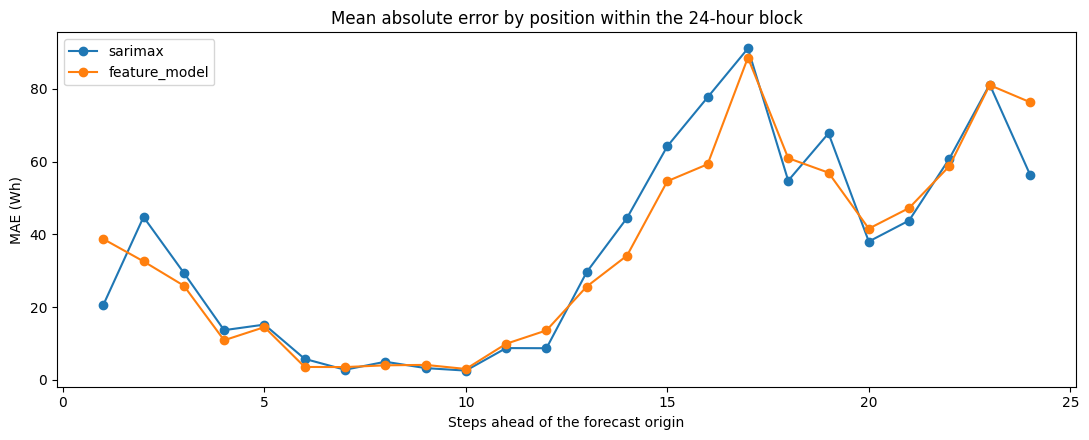

SARIMAX MAE at step  1: 20.55
SARIMAX MAE at step 24: 56.43


In [24]:
step = np.tile(np.arange(1, config.HORIZON + 1),
               len(test_full) // config.HORIZON)

by_step = pd.DataFrame({
    "step_ahead": step,
    "sarimax": np.abs(forecasts["sarimax"].values - test_full.values),
    "feature_model": np.abs(feature_pred.reindex(test_full.index).values
                             - test_full.values),
}).groupby("step_ahead").mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
by_step.plot(ax=ax, marker="o")
ax.set_title("Mean absolute error by position within the 24-hour block")
ax.set_ylabel("MAE (Wh)")
ax.set_xlabel("Steps ahead of the forecast origin")
fig.tight_layout()
plotting.save_fig(fig, config.FIGURE_DIR / "05_error_by_step_ahead.png")
plt.show()

print(f"SARIMAX MAE at step  1: {by_step.loc[1, 'sarimax']:.2f}")
print(f"SARIMAX MAE at step 24: {by_step.loc[24, 'sarimax']:.2f}")

SARIMAX is roughly three times more accurate at step 1 than at step 24, even though step 1 falls in the evening peak where demand is hardest to predict -- the short horizon is doing that work. The feature model has no such gradient, since every one of its predictions is 24 hours ahead; its variation across the block simply tracks time of day.

So the feature model achieves a lower overall error *while carrying a handicap*. Its genuine 24-hour-ahead skill is at least as good as SARIMAX's, and probably better.

## 12. What the model relies on

Saved figure to D:\UK ass\outputs\figures\feature_importance.png


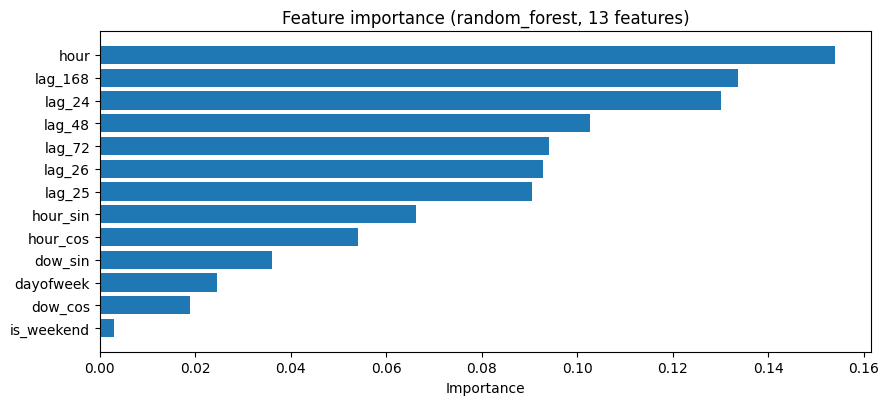

hour          0.1539
lag_168       0.1336
lag_24        0.1300
lag_48        0.1026
lag_72        0.0941
lag_26        0.0927
lag_25        0.0906
hour_sin      0.0662
hour_cos      0.0540
dow_sin       0.0360
dayofweek     0.0245
dow_cos       0.0189
is_weekend    0.0029
dtype: float64

In [25]:
importance = feature_models.get_feature_importance(
    final_model, list(sel["X_test"].columns))

fig = plotting.plot_feature_importance(
    importance, top_n=15,
    title=f"Feature importance ({best_family}, {len(chosen_cols)} features)")
plotting.save_fig(fig, config.FIGURE_DIR / "feature_importance.png")
plt.show()

importance.round(4)

In [26]:
# Importance measured on the full 50-feature model, for contrast.
imp_all = feature_models.get_feature_importance(
    model_all, list(allf["X_test"].columns))
groups_all = features.feature_groups(table.columns)

feature_models.group_importance(imp_all, groups_all).round(4)

,group,n_features,total_importance,mean_importance
0,indoor,24,0.3282,0.0137
1,calendar,7,0.2294,0.0328
2,lag,6,0.2026,0.0338
3,rolling,6,0.1272,0.0212
4,outdoor,6,0.0745,0.0124
5,house,1,0.0381,0.0381


Worth noting the tension here: on the 50-feature model the indoor sensors collect a large share of the total importance, yet the ablation showed they *hurt* accuracy. Split-based importance measures how often a feature was used, not whether using it helped -- with 24 highly collinear sensor columns there are always plausible-looking splits available. The ablation is the more reliable evidence, which is why selection was driven by it.

## 13. Save outputs

In [27]:
feature_models.save_model(final_model)
feature_models.save_selection({
    "chosen_groups": chosen_groups,
    "chosen_columns": chosen_cols,
    "model_family": best_family,
    "validation_scores": dict(zip(family_df["model"], family_df["MASE"])),
    "selection_metric": "MASE",
})

ablation.to_csv(config.FEATURE_ABLATION_PATH, index=False)
importance.to_csv(config.FEATURE_IMPORTANCE_PATH, header=["importance"])
results.to_csv(config.METRICS_DIR / "feature_model_comparison.csv", index=False)
feature_pred.to_frame().to_csv(config.FORECAST_DIR / "feature_model_forecast.csv")

print("Saved feature-model outputs.")

Saved feature model to D:\UK ass\outputs\model_objects\feature_model.pkl
Saved feature-model selection to D:\UK ass\outputs\metrics\feature_model_selection.json
Saved feature-model outputs.
